In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

You'll want to tweak these parameters to match the values you have setup in your ensemble. 

In [2]:
max_steps =100
step_size = 10
ts = [x * step_size for x in range(1, int(max_steps / step_size) + 1)]


In [4]:
df = pd.read_csv("./chain_outputs_10.csv")

for t in ts[1:]: 

    df2 = pd.read_csv(f"./chain_outputs_{t}.csv")
    df = pd.concat([df,df2],ignore_index=True)

In [5]:
df

,Unnamed: 0,CountySplits,MM,EG,PB,DWins,PP,Comp45-55
0,0,9,-0.008338,-0.191187,-0.071429,0,4.902059,1
1,1,6,-0.007568,-0.191187,-0.071429,0,4.696264,1
2,2,5,-0.007238,-0.191187,-0.071429,0,4.109455,1
3,3,5,-0.007321,-0.191187,-0.071429,0,4.090148,1
4,4,6,-0.007138,-0.191187,-0.071429,0,4.006737,1
...,...,...,...,...,...,...,...,...
94,5,7,-0.018947,-0.191187,-0.071429,0,4.401360,1
95,6,8,-0.018938,-0.191187,-0.071429,0,4.476451,1
96,7,8,-0.019211,-0.191187,-0.214286,0,4.687002,1
97,8,8,-0.019145,-0.191187,-0.214286,0,4.978259,1


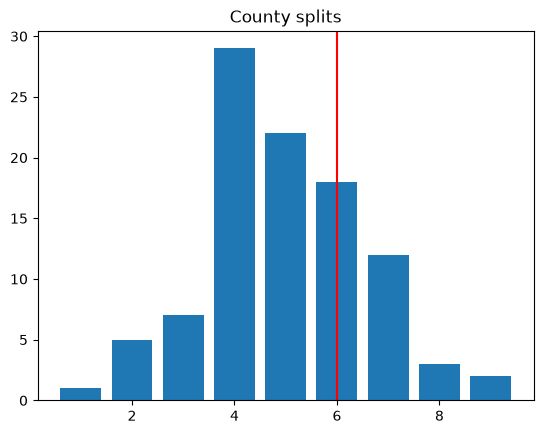

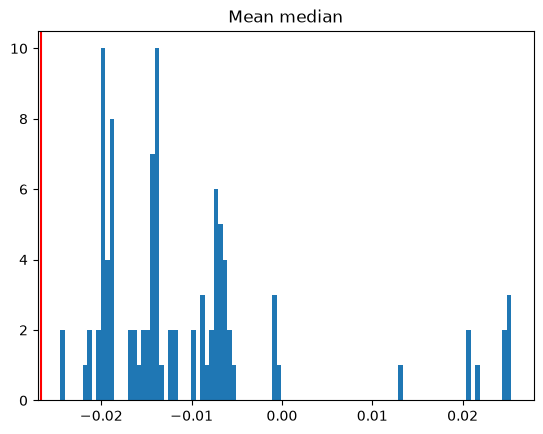

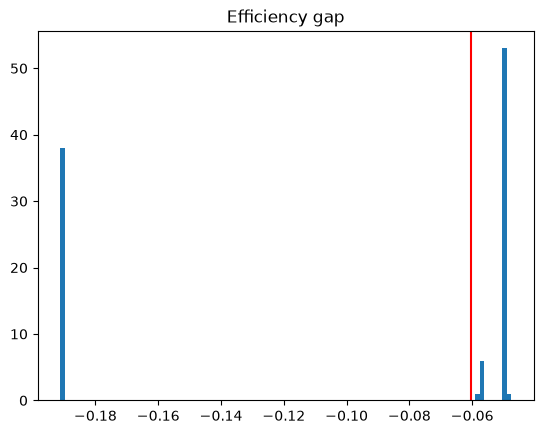

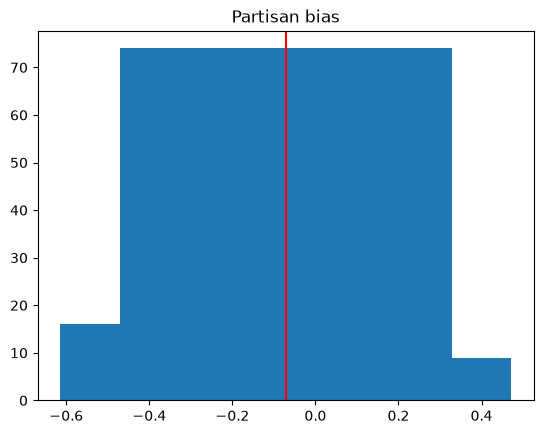

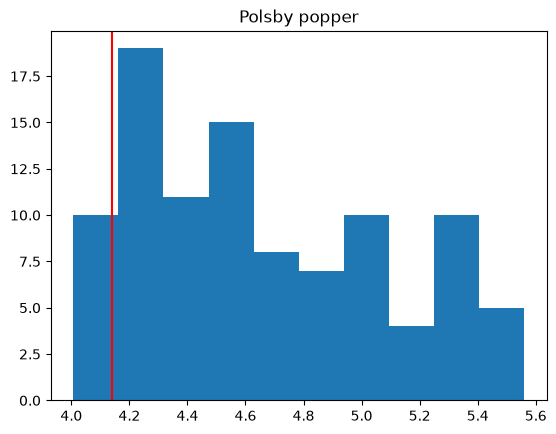

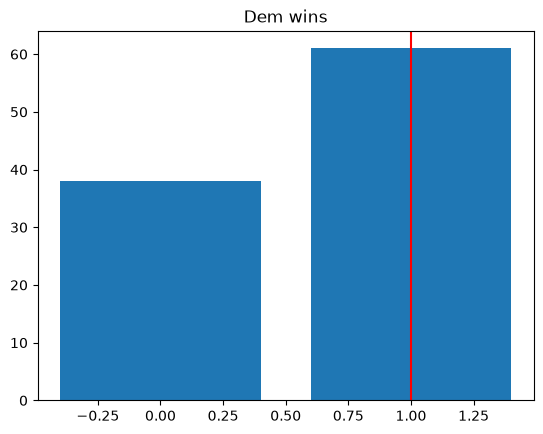

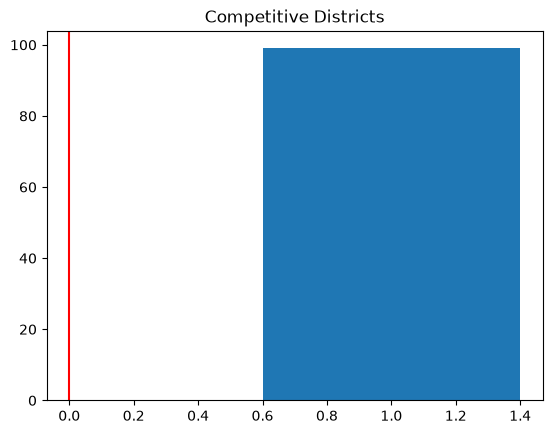

In [7]:
counts = Counter(df['CountySplits'])

categories = list(counts.keys())
frequencies = list(counts.values())
plt.bar(categories, frequencies)
plt.axvline(6, color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(df['MM'],bins=100)
plt.axvline(-0.026663889851555544, color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(df['EG'],bins=100)
plt.axvline(-0.06025134349487188, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

#plt.hist(df['PB'])

counts = Counter(df['PB'])
categories = list(counts.keys())
frequencies = list(counts.values())
plt.bar(categories, frequencies)
plt.axvline(-0.07142857142857145, color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()


plt.hist(df['PP'])
plt.axvline(4.141487705294307, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

counts = Counter(df['DWins'])

categories = list(counts.keys())
frequencies = list(counts.values())

plt.bar(categories, frequencies)
plt.axvline(1, color='red',label='Enacted')
plt.title("Dem wins")
plt.show()


counts = Counter(df['Comp45-55'])

categories = list(counts.keys())
frequencies = list(counts.values())

plt.bar(categories, frequencies)
plt.axvline(0, color='red',label='Enacted')
plt.title("Competitive Districts")
plt.show()

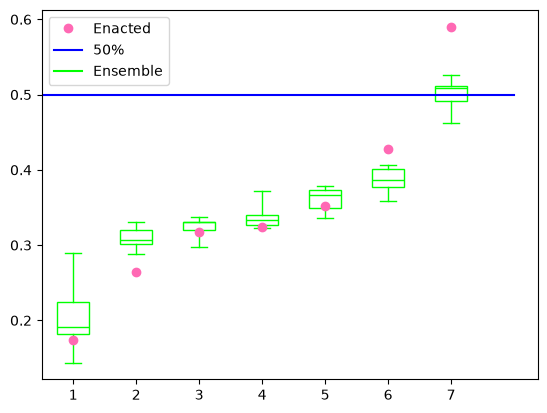

In [8]:
a = []
for t in ts:
    tempvotes = np.loadtxt(f"./DemPercs_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s, :])

a = np.array(a)

c='lime'

medianprops = dict(color="black")

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
# ax1.add_patch(patches.Rectangle((0, .37), 35, .18,color='honeydew'))
# plt.plot([0,34], [.55, .55], 'lightgreen')
# plt.plot([0,34], [.37, .37], 'lightgreen')
plt.boxplot(
    a,
    whis=[1, 99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c, markeredgecolor=c),
    medianprops=dict(color=c),
)

plt.plot(range(1, 8), [0.17411410179063067, 0.2647423365405502, 0.31798924681486956, 0.32347804683654097,
                       0.35225624913685954, 0.4280245049427976, 0.5903890707544268], "o", color="hotpink", label="Enacted")

#plt.plot([0.5, 8], [0.4, 0.4], color="yellow", label="40%")
plt.plot([0.5, 8], [0.5, 0.5], color="blue", label="50%")
plt.plot([],[],color='lime',label='Ensemble')
plt.legend()
#plt.ylim([0, 0.7])



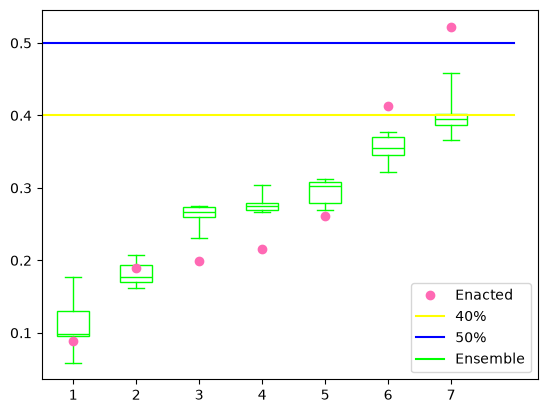

In [9]:
a = []
for t in ts:
    tempvotes = np.loadtxt(f"./BlackPercs_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        a.append(tempvotes[s, :])

a = np.array(a)

c='lime'

medianprops = dict(color="black")

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
# ax1.add_patch(patches.Rectangle((0, .37), 35, .18,color='honeydew'))
# plt.plot([0,34], [.55, .55], 'lightgreen')
# plt.plot([0,34], [.37, .37], 'lightgreen')
plt.boxplot(
    a,
    whis=[1, 99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c, markeredgecolor=c),
    medianprops=dict(color=c),
)

plt.plot(range(1, 8), [0.08832616771772982,
 0.1888657336835848,
 0.19869374110072432,
 0.21514372022222006,
 0.2614083997858687,
 0.4124959005240351,
 0.5226218113810038], "o", color="hotpink", label="Enacted")

plt.plot([0.5, 8], [0.4, 0.4], color="yellow", label="40%")
plt.plot([0.5, 8], [0.5, 0.5], color="blue", label="50%")
plt.plot([],[],color='lime',label='Ensemble')
plt.legend()
#plt.ylim([0, 0.7])

